In [47]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("diabetes.csv")

In [18]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
data.duplicated().sum()

np.int64(0)

In [56]:
X = data.drop("Outcome",axis=1)
y = data["Outcome"]

In [22]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

In [23]:
from sklearn.linear_model import LogisticRegression

lg_ml = LogisticRegression()

lg_ml.fit(X_train, y_train)

/home/jahanzeb/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
y_pred_train = lg_ml.predict(X_train)
y_pred_test = lg_ml.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

acc_score_train = accuracy_score(y_train, y_pred_train)
acc_score_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy Score in Training data: {acc_score_train}")
print(f"Accuracy Score in Testing data: {acc_score_test}")

Accuracy Score in Training data: 0.7916666666666666
Accuracy Score in Testing data: 0.7291666666666666


In [26]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


 # Accuracy , Precision and Recall 

In [29]:
from sklearn.metrics import precision_score, recall_score, accuracy_score , classification_report



precision_score(y_train,y_pred_train)
recall_score(y_train,y_pred_train)

0.5970149253731343

In [31]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       375
           1       0.75      0.60      0.67       201

    accuracy                           0.79       576
   macro avg       0.78      0.75      0.76       576
weighted avg       0.79      0.79      0.79       576



In [32]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       125
           1       0.64      0.52      0.57        67

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.69       192
weighted avg       0.72      0.73      0.72       192



In [13]:
data.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [14]:
class_0 = data[data["Outcome"] == 0].sample(268)

In [33]:
class_1 = data[data["Outcome"] == 1]

In [35]:
data_2 =  pd.concat([class_0,class_1], axis=0).sample(536)

In [36]:
data_2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
468,8,120,0,0,0,30.0,0.183,38,1
56,7,187,68,39,304,37.7,0.254,41,1
543,4,84,90,23,56,39.5,0.159,25,0
170,6,102,82,0,0,30.8,0.180,36,1
626,0,125,68,0,0,24.7,0.206,21,0
...,...,...,...,...,...,...,...,...,...
366,6,124,72,0,0,27.6,0.368,29,1
258,1,193,50,16,375,25.9,0.655,24,0
98,6,93,50,30,64,28.7,0.356,23,0
235,4,171,72,0,0,43.6,0.479,26,1


In [53]:
X = data_2.drop("Outcome",axis=1)
y = data_2["Outcome"]

In [38]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

In [39]:
from sklearn.linear_model import LogisticRegression

lg_ml = LogisticRegression()

lg_ml.fit(X_train, y_train)

/home/jahanzeb/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred_train = lg_ml.predict(X_train)
y_pred_test = lg_ml.predict(X_test)

In [41]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.77      0.76      0.76       201
           1       0.76      0.78      0.77       201

    accuracy                           0.77       402
   macro avg       0.77      0.77      0.77       402
weighted avg       0.77      0.77      0.77       402



In [42]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        67
           1       0.73      0.70      0.72        67

    accuracy                           0.72       134
   macro avg       0.72      0.72      0.72       134
weighted avg       0.72      0.72      0.72       134



# SMOTE (Synthetic Minority Over-sampling Technique)

In [43]:
# check version number
import imblearn
print(imblearn.__version__)

0.14.0


In [44]:
from imblearn.over_sampling import SMOTE

In [60]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X, y = smote.fit_resample(X, y)
y.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

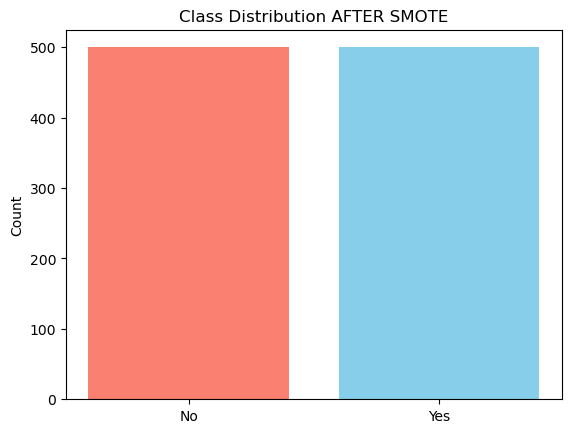

In [58]:
plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['No', 'Yes'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()


In [61]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

In [62]:
from sklearn.linear_model import LogisticRegression

lg_ml = LogisticRegression()

lg_ml.fit(X_train, y_train)

/home/jahanzeb/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred_train = lg_ml.predict(X_train)
y_pred_test = lg_ml.predict(X_test)

In [64]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       375
           1       0.76      0.74      0.75       375

    accuracy                           0.75       750
   macro avg       0.75      0.75      0.75       750
weighted avg       0.75      0.75      0.75       750



In [ ]:
print(classification_report(y_train,y_pred_train))